### Imports

In [1]:
# Import modules
from matplotlib import pyplot as plt
from mpmath import zeta, pi
import matplotlib as mpl
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from jax import config
import numpy as np
import jax.numpy as jnp
import os
#from discodj import DiscoDJ
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version

0.7.2


### Setting to enable only if you want to save the plot 

In [19]:
mpl.use("pgf")
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
})

### Reset plot settings

In [3]:
mpl.rcParams.update(mpl.rcParamsDefault)

### Simulation settings
DISCO-DJ can be run on a GPU (*much* faster) or on a CPU. The following cell detects if a GPU is available and sets the device accordingly.

In [3]:
# Detect if a GPU is available
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"

# All parameters


In [2]:
### Conversion factors
conKeV = 1.160451812e4  # conversion K/eV : 
conv_ev3_to_cm3 = (5.0677307e4)**3  # conversion eV3 / cm3


### Others ### 
k_B = 8.617e-5  # eV/K
Tcmb = 2.725  #  CMB temp (K)
Tnu0 = (4/11)**(1/3)*Tcmb # CNB temp (K) 
Tnu0_eV = Tnu0/conKeV # CNB temps (eV)
c_kms = 299792.458  # km/s


### NEUTRINOS ###
mnu = 0.3/3 # Sum of neutrinos mass eV (Note that here we have 3 neutrino but only one massive with all the mass)
smnu = 0.3
Neff = 0 # Effective number of neutrino 
N_massive_nu = 3 # Number of massive neutrinos
g=2 # DoF
amnu = mnu * conKeV / Tnu0 # parameter amnu pour nu_background 


### Cosmology ###
Omega_c=0.269984542
Omega_b=0.049
Omega_k=0.0
h=0.67
n_s=0.9667
sigma8=0.8159
w0=-1.0
wa=0.0
H0=h*100
Omega_m0 = Omega_c + Omega_b
rho_c = 10.54e3 * h**2 / conv_ev3_to_cm3   # 4.2e-11(eV4)
Omega_gamma_0 = 2.47e-5 / h**2 #Initial photon density parameter 

# Neutrinos energy density 

### Gauss-Laguerre coeff function 

In [4]:
def generalized_gauss_laguerre_weights(n, alpha):
    """
    Compute nodes and weights for n-point generalized Gauss-Laguerre quadrature,
    which approximates integrals of the form
        ∫₀∞ x^α f(x) e^(-x) dx.
    
    Parameters:
        n : int
            Number of quadrature points.
        alpha : float
            The parameter in the weight function x^α e^(-x).
    
    Returns:
        nodes : ndarray
            The quadrature nodes (abscissae).
        weights : ndarray
            The quadrature weights.
    """
    # Indices i = 1, 2, ..., n.
    i = jnp.arange(1, n+1)
    
    # Diagonal entries: a_i = 2i - 1 + alpha.
    a = 2*i - 1 + alpha
    
    # Off-diagonal entries for i = 1, ..., n-1: b_i = sqrt(i*(i+alpha))
    i_off = jnp.arange(1, n)
    b = jnp.sqrt(i_off * (i_off + alpha))
    
    # Construct the symmetric tridiagonal Jacobi matrix.
    J = jnp.diag(a) + jnp.diag(b, 1) + jnp.diag(b, -1)
    
    # Compute eigenvalues (nodes) and eigenvectors.
    nodes, V = jnp.linalg.eigh(J)
    
    # The weights are given by the square of the first component of the eigenvectors,
    # multiplied by the zeroth moment: Γ(α+1).
    if type(alpha) == int:
      weights = (V[0, :]**2) * jax.scipy.special.factorial(alpha)
    else:
      weights = (V[0, :]**2) * jax.scipy.special.gamma(alpha + 1)
    
    return nodes, weights

### Neutrinos momentum bins and energy density 

In [5]:
def get_neutrino_momentum_bins(  nqmax : int ) -> tuple[jax.Array, jax.Array]:
    """Get the momentum bins and integral kernel weights for neutrinos

    Args:
        nqmax (int): Number of momentum bins.

    Returns:
        jax.Array: q, w
    """
    # fermi_dirac_const = 7 * np.pi**4 / 120
    fermi_dirac_const = 5.682196976983475

    # nqmax = 3,4,5 are from high accuracy formulas from CAMB, higher values resort to modified Gauss-Laguerre, 
    # which is not pre-computed however
    if nqmax == 3:
        q = jnp.array([0.913201, 3.37517, 7.79184])
        dlfdlq = -q/(1+jnp.exp(-q))
        w = jnp.array([0.0687359, 3.31435, 2.29911]) / (-0.25*dlfdlq)
    elif nqmax == 4:
        q = jnp.array([0.7, 2.62814, 5.90428, 12.0])
        dlfdlq = -q/(1+jnp.exp(-q))
        w = jnp.array([0.0200251, 1.84539, 3.52736, 0.289427]) / (-0.25*dlfdlq)
    elif nqmax == 5:
        q = jnp.array([0.583165, 2.0, 4.0, 7.26582, 13.0])
        dlfdlq = -q/(1+jnp.exp(-q))
        w = jnp.array([0.0081201, 0.689407, 2.8063, 2.05156, 0.12681]) / (-0.25*dlfdlq)
    else:
        alpha = 1
        q, w = generalized_gauss_laguerre_weights( nqmax, alpha )
        w *= q**3 / (1 + jnp.exp(-q)) * q**-alpha
    
    return q, w


def nu_background( a : float, amnu: float, nq : int = 8 ) -> tuple[float, float, float]:
    """ computes the neutrino density and pressure of one flavour of massive neutrinos
        in units of the mean density of one flavour of massless neutrinos

    Args:
        a (float): scale factor
        amnu (float): neutrino mass in units of neutrino temperature (m_nu*c**2/(k_B*T_nu0).
        nq (int, optional): number of integration points. Defaults to 8.

    Returns:
        tuple[float, float, float]: rho_nu/rho_nu0, p_nu/p_nu0, pp_nu/pp_nu0
    """
    
    # q is the comoving momentum in units of k_B*T_nu0/c.
    v    = lambda q: 1 / jnp.sqrt(1 + (a * amnu / q)**2)   # = (1/aq) / sqrt(1+1/aq**2)
    
    q, w = get_neutrino_momentum_bins( nq )
    rhonu = jnp.dot( w, 1. / v(q) )
    pnu = jnp.dot( w, v(q) / 3 )
    ppnu = jnp.dot( w, v(q)**3 / 3 )
    
    return rhonu, pnu, ppnu


### Plot of neutrino energy density

In [20]:
# scale factor array
a = jnp.geomspace(1e-6, 1.0, 500) # a(ini) has to be small enough to ensure convergence of the ODE of D 
x_array = jnp.linspace(jnp.log(a[0]), jnp.log(a[-1]), 500)
a_array = jnp.exp(x_array)

# neutrino density rho_nu(a)
rho_nu = jax.vmap(lambda aa: nu_background(aa, amnu)[0])(a)

# Transfo ev4
rho_nu = rho_nu * g * (Tnu0/conKeV)**4 / 2 / jnp.pi**2 / a**4

# Density of neutrinos today 
rho0 = rho_nu[-1]  
n_nu0 = rho0 / mnu * conv_ev3_to_cm3
n_nu0_th = g * (3 * zeta(3) / (4 * pi**2)) * (Tnu0/conKeV)**3 * conv_ev3_to_cm3
print("Neutrino density today (theoretical formula) : n_nu0_Th(cm-3) =", n_nu0_th)
print("Neutrino density today from computed neutrido density : n_nu0 (cm-3) =", n_nu0)


#  Reference lines 
rho_ref_a4 = rho_nu[0] * (a / a[0])**(-4)  
rho_ref_a3 = rho_nu[-1] * (a / a[-1])**(-3)  

diff = rho_ref_a4 - rho_ref_a3
cross_indices = jnp.where(diff[:-1] * diff[1:] < 0)[0]
idx_cross = cross_indices[0]
a_cross = a[idx_cross]


# Plot 
plt.figure(figsize=(6, 4))
plt.loglog(a, rho_nu,color='blue', label=r'$\rho_\nu(a)$',lw=2)  
plt.loglog(a[:idx_cross], rho_ref_a4[:idx_cross], 'r--', label=r'$a^{-4}$',lw=2)  
plt.loglog(a[idx_cross:], rho_ref_a3[idx_cross:], 'y--', label=r'$a^{-3}$',lw=2)  
plt.axvline(a_cross, color='grey', linestyle=':', label=r'transition',lw=2)  
#plt.axvline(a_nr_val, color="k", ls="--", alpha=0.6, label="a_nr")
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$\rho_\nu (eV^4)$')
#plt.title('Massive neutrino density as a function of scale factor')
plt.grid(True, which='both', ls='--')
plt.legend(loc=1,prop={'size': 13})
plt.show()
plt.savefig('rhonu.pgf')

Neutrino density today (theoretical formula) : n_nu0_Th(cm-3) = 111.9547742544
Neutrino density today from computed neutrido density : n_nu0 (cm-3) = 111.95419


# Energy density parameter


In [10]:
def Onu(a , amnu):
        """Compute the exact massive neutrino density parameter and its derivative"""
        a_arr = jnp.atleast_1d(a)

        def one_a(aa):
            return (
                N_massive_nu * nu_background(aa, amnu)[0]
                * g * (Tnu0 / conKeV) ** 4
                / (2 * jnp.pi ** 2 * rho_c)
                * aa ** (-4)
            )
        out = jax.vmap(one_a)(a_arr)
        return out[0] if jnp.asarray(a).ndim == 0 else out

def interp(x, xp, yp):
    """Linear interpolation function"""
    idx = jnp.clip(jnp.searchsorted(xp, x) - 1, 0, xp.shape[0] - 2)

    x0 = xp[idx]
    x1 = xp[idx + 1]
    y0 = yp[idx]
    y1 = yp[idx + 1]

    t = (x - x0) / (x1 - x0)
    return y0 + t * (y1 - y0)

Omega_nu_table = None
dOmega_nu_table = None
Omega_nu0_table = None
dOmega_nu0_table = None

def Compute_Omega_nu(m):
    global Omega_nu_table, dOmega_nu_table

    Omega_nu_table = jax.vmap(
        lambda _a: Onu(_a, m * conKeV / Tnu0)
    )(a)

    dOmega_nu_table = jax.vmap(
        lambda _a: jax.grad(Onu)(_a, m * conKeV / Tnu0)
    )(a)

def Compute_Omega_nu0(m):
    global Omega_nu0_table, dOmega_nu0_table

    Omega_nu0_table = jax.vmap(
        lambda _a: Onu(_a, 0 * conKeV / Tnu0)
    )(a)

    dOmega_nu0_table = jax.vmap(
        lambda _a: jax.grad(Onu)(_a, 0 * conKeV / Tnu0)
    )(a)

Compute_Omega_nu(mnu)
Compute_Omega_nu0(0)

In [11]:
def Omega_nu(x):
    """Compute the interpolated massive neutrino density parameter"""
    return interp(x, a, Omega_nu_table)

def dOmega_nu(x):
    """Compute the derivative of interpolated massive neutrino density parameter"""
    return interp(x, a, dOmega_nu_table)

def Omega_nu0(x):
    """Compute the interpolated massive neutrino density parameter"""
    return interp(x, a, Omega_nu0_table)

def dOmega_nu0(x):
    """Compute the derivative of interpolated massive neutrino density parameter"""
    return interp(x, a, dOmega_nu0_table)

In [12]:
#Vectorize
Omega_nu_array = Omega_nu(a)

# Friedmann equation


### Functions 

In [13]:
def Omega_de(Omega_c , Omega_b ,Omega_k,Omega_gamma_0):
    """Compute the dark energy density parameter with massless neutrinos."""
    return 1.0 - Omega_c - Omega_b - Omega_k - Omega_gamma_0 - Omega_nu0(1)

def Omega_de_wnu(Omega_c , Omega_b ,Omega_k,Omega_gamma_0):
    """Compute the dark energy density parameter with massive neutrinos."""
    return 1.0 - Omega_c - Omega_b - Omega_k - Omega_nu(1) - Omega_gamma_0 

########

def Omega_de_of_a(Omega_de, w0 ,wa, a):
    """Dark energy density term as a function of scale factor."""
    return Omega_de * (a ** (-3 * (1 + w0 + wa)) * jnp.exp(-3 * wa * (1 - a)))
########

def Omega_nu_rel (Neff, Nnu) : 
    return Omega_gamma_0 * (Neff - Nnu) * (7/8) * (4/11)**(4/3) 

#Inital Dark energy density parameter with massless/massive neutrinos
Omega_de0 = Omega_de(Omega_c , Omega_b ,Omega_k, Omega_gamma_0) 
Omega_de0_wnu = Omega_de_wnu(Omega_c , Omega_b ,Omega_k,Omega_gamma_0)          
print(Omega_b+Omega_c+Omega_de0 +Omega_k+Omega_nu0(1)+Omega_gamma_0)   #RETURN 1
print( Omega_c + Omega_b + Omega_k + Omega_nu(1) + Omega_gamma_0 +Omega_de0_wnu)  #RETURN 1

########

def Hubble_const (Omega_c , Omega_b ,Omega_k, a) :
    """Compute the Hubble parameter with massless neutrinos"""
    return H0 *jnp.sqrt( ((Omega_gamma_0) *a**(-4) + (Omega_b + Omega_c) *a**(-3) + Omega_k *a**(-2) + Omega_de_of_a(Omega_de0, w0 ,wa, a)+Omega_nu0(a)) )

def Hubble_const_wnu (Omega_c , Omega_b ,Omega_k, a) :
    """Compute the Hubble parameter with massive neutrinos"""
    return H0 * jnp.sqrt( ((Omega_gamma_0) *a**(-4) + (Omega_b + Omega_c) *a**(-3) + Omega_k *a**(-2) + Omega_de_of_a(Omega_de0_wnu, w0 ,wa, a) + Omega_nu(a)) )


1.0
1.0


In [21]:
#Omega comparaisom sim / theory
#Omega_nu0 = Omega_nu(1)
Omega_nu1 = Omega_nu_array[0]/a[0]**(-4)
print("Omega_nu(a=0) =",Omega_nu1 )
print("Energy density parameter from computed energy density : Omega_nu(a=1) =", Omega_nu(1))
print("Energy density parameter from theoretical formula : Omega_nu_th(a=1)= ", smnu / 94 / h**2)
print(1-6*Omega_nu(1)/(Omega_c+Omega_b))

#Plot
plt.figure(figsize=(6,4))
plt.loglog(
    a, Omega_gamma_0 * a**-4,
    color='#1f77b4',
    lw=2,
    ls='-',
    label=r'$\Omega_\gamma$'
)
plt.loglog(
    a, Omega_nu_array,
    color='#17becf',
    lw=2,
    ls='-.',
    label=r'$\Omega_\nu$'
)
plt.loglog(
    a, (Omega_b + Omega_c) * a**-3,
    color='#ff7f0e',
    lw=2,
    ls='-',
    label=r'$\Omega_b+\Omega_c$'
)
plt.loglog(
    a,
    Omega_de_of_a(Omega_de0_wnu, w0, wa, a),
    color='#2ca02c',
    lw=2,
    ls=':',
    label=r'$\Omega_\Lambda$'
)
#plt.loglog(a[:100], Omega_a4[:100], 'r--', lw=2, label=r'$a^{-4}$ (radiation)')
#plt.loglog(a[400:], Omega_a3[400:], 'y--', lw=2, label=r'$a^{-3}$ (matter)')
#plt.axvline(a[jnp.argmin(jnp.abs(Omega_nu_array-Omega_a3))], color='grey', linestyle=':', lw=2, label='transition')
plt.xlabel('Scale factor $a$')
plt.ylabel(r'$\Omega_i(a)$')
plt.grid(True, which='both', ls='--')
plt.legend(prop={'size': 13})
#plt.title('Neutrino density parameter vs scale factor')
plt.show()
plt.savefig('omega.pgf')

Omega_nu(a=0) = 3.7494297e-05
Energy density parameter from computed energy density : Omega_nu(a=1) = 0.007098579
Energy density parameter from theoretical formula : Omega_nu_th(a=1)=  0.0071095775489020425
0.86647797


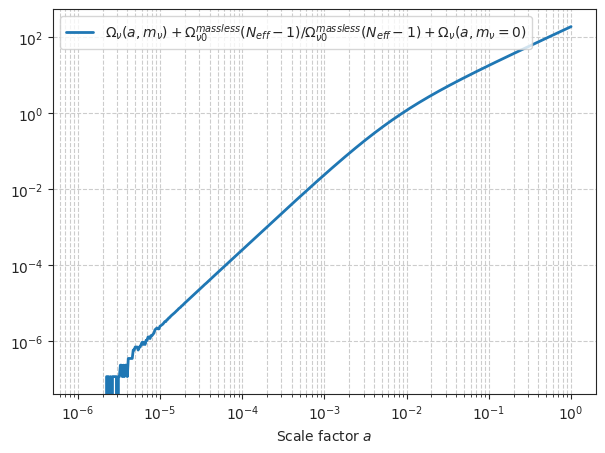

In [15]:
#Test of numerical precision 

plt.figure(figsize=(7.0, 5.0)) 
plt.loglog(a,  (Omega_nu(a)) / (Onu(a,0))-1,label=r'$\Omega_{\nu}(a,m_{\nu}) +\Omega_{\nu 0}^{massless}(N_{eff}-1) / \Omega_{\nu 0}^{massless}(N_{eff}-1)+\Omega_{\nu}(a,m_{\nu}=0)$',lw=2)  
plt.xlabel(r'Scale factor $a$')
plt.grid(True, which='both', ls='--')
plt.legend(loc="upper left")
plt.show()
#plt.savefig('H_acc.pgf')

### Computation and plot

In [16]:
print(type(Omega_nu0))

<class 'function'>


In [17]:
#Computation of Hubble constant H with massless/massive neutrinos 
H = Hubble_const(Omega_c , Omega_b ,Omega_k, a)
H_wnu = jnp.array([Hubble_const_wnu(Omega_c, Omega_b, Omega_k, ai) for ai in a])

In [22]:
#Plot H vs H_wnu

# Style global
mpl.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.1,
})

fig, ax = plt.subplots(figsize=(6, 4))
# Courbe principale
ax.loglog(
    a, (H/H0)**2,
    color='black',
    lw=2.0,
    alpha=0.75,
    label=r'$E^2(a)$',
    zorder=2
)
# Courbe avec neutrinos mise en avant
ax.loglog(
    a, (H_wnu/H0)**2,
    color='#d62728',
    lw=2.8,
    ls=(0, (6, 3)),
    label=r'$E_\nu^2(a)$',
    zorder=10
)
# --- Components ---
ax.loglog(
    a, Omega_gamma_0 * a**-4,
    color='#1f77b4',
    lw=2,
    ls='-',
    label=r'$\Omega_\gamma$'
)
ax.loglog(
    a, Omega_nu_array,
    color='#17becf',
    lw=2,
    ls='-.',
    label=r'$\Omega_\nu$'
)
ax.loglog(
    a, (Omega_b + Omega_c) * a**-3,
    color='#ff7f0e',
    lw=2,
    ls='-',
    label=r'$\Omega_b+\Omega_c$'
)
ax.loglog(
    a,
    Omega_de_of_a(Omega_de0_wnu, w0, wa, a),
    color='#2ca02c',
    lw=2,
    ls=':',
    label=r'$\Omega_\Lambda$'
)
# Labels
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'Energy density contribution')

# Grid
ax.grid(
    True,
    which='both',
    ls='--',
    alpha=0.35
)

# Legend
ax.legend(
prop={'size': 13}
)

# Margins
ax.set_xlim(a.min(), a.max())

plt.tight_layout()

# Save BEFORE show
plt.savefig("H.pgf", bbox_inches='tight')

plt.show()


#Plot relative deviation [(H_wnu/H)-1]
plt.figure(figsize=(6, 4))
plt.semilogx(a, abs(H_wnu/H),color='blue',lw=2)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$H_{\nu}/H$')
plt.grid(True, which='both', ls='--')
plt.show()
plt.savefig('Hdiff.pgf')

#Print conpute Hubble const today (to be compared with theoretical value fixed in cosmology)
print('Hubble constant today : H0(a=1)',H[-1])

Hubble constant today : H0(a=1) 66.99999


# Linear and Second order growth factor

### Functions for Energy E2 and derivatives 

In [24]:
def E2(a):
    """Computation of E^2 with massless neutrinos"""
    return ((Omega_gamma_0) * a**(-4)
    +Omega_m0 * a**(-3)
    +Omega_k * a**(-2)
    +Omega_de_of_a(Omega_de0, w0, wa, a))
    +Omega_nu0(a)

def E2_nu(a):
    """Computation of E^2 with massive neutrinos"""
    return ((Omega_gamma_0) * a**(-4)
    +Omega_m0 * a**(-3)
    +Omega_k * a**(-2)
    +Omega_de_of_a(Omega_de0_wnu, w0, wa, a)
    +Omega_nu(a))

########

def fdE_da(a):
    """Computation of dE/da with massless neutrinos"""
    dE2 = (
        -4 * (Omega_gamma_0) * a**(-5)
        -3 * Omega_m0 * a**(-4)
        -2 * Omega_k * a**(-3)
        + jax.grad(lambda x: Omega_de_of_a(Omega_de0, w0, wa, x))(a)
        + dOmega_nu0(a)
    )
    return 0.5 * dE2 / jnp.sqrt(E2(a))

def fdE_da_nu(a):
    """Computation of dE/da with massive neutrinos"""
    dE2 = (
        -4 * (Omega_gamma_0) * a**(-5)
        -3 * Omega_m0 * a**(-4)
        -2 * Omega_k * a**(-3)
        + jax.grad(lambda x: Omega_de_of_a(Omega_de0_wnu, w0, wa, x))(a)
        + dOmega_nu(a)
    )

    return 0.5 * dE2 / jnp.sqrt(E2_nu(a))

########

def dlnHdx(a,E,dE) :
    """Compute dln(H)/dln(a) use in the drag coef""" 
    return (a/2/E(a))*(dE(a))



### Current matter density parameter 

In [25]:
def Omega_m(a):
    """Compute the dynamic fraction of matter with massless neutrinos"""
    return Omega_m0 * a**(-3) / E2(a)

def Omega_m_nu(a):
    """Compute the dynamic fraction of matter with massive neutrino and free-streaming if k given"""
    Omega_cb_a = (Omega_m0 * a**(-3)) / E2_nu(a)
    return Omega_cb_a 

### ODE of linear (D) and second order (E) growth functions and RK4

In [26]:
def Ode(x, y):
    """ODEs of D and E in log(a) variable for massless neutrinos"""
    D, Dx, E, Ex = y
    a = jnp.exp(x)
    Dxx = (3/2) * Omega_m(a) * D - (2+dlnHdx(a,E2,fdE_da)) * Dx
    Exx = (3/2) * Omega_m(a) * (E-D**2) - (2+dlnHdx(a,E2,fdE_da)) * Ex
    return jnp.array([Dx, Dxx, Ex, Exx])

def Ode_nu(x, y):
    """ODEs of D and E in log(a) variable for massive neutrinos without free streaming"""
    D, Dx, E, Ex = y
    a = jnp.exp(x)
    Omega_eff = Omega_m_nu(a)
    Dxx = (3/2) * Omega_eff * D - (2 + dlnHdx(a, E2_nu, fdE_da_nu)) * Dx
    Exx = (3/2) * Omega_eff * (E - D**2) - (2 + dlnHdx(a, E2_nu, fdE_da_nu)) * Ex
    return jnp.array([Dx, Dxx, Ex, Exx])

########    

def rk4_integrate(func, y0, t_array):
    """Integrates using RK4 method with jax.lax.scan for variable time steps.
    
    :param func: Function representing the ODE (dy/dt = func(t, y)).
    :param y0: Initial value of y.
    :param t_array: Array of time steps where integration is evaluated.
    :return: Array of y values corresponding to t_array.
    """

    def rk4_step(carry, t_next):
        """Performs a single RK4 step."""
        y, t = carry
        dt = t_next - t
        k1 = func(t, y)
        k2 = func(t + dt / 2, y + dt / 2 * k1)
        k3 = func(t + dt / 2, y + dt / 2 * k2)
        k4 = func(t + dt, y + dt * k3)
        y_out = y + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        return (y_out, t_next), y_out

    # Perform scan
    _, y_values = jax.lax.scan(rk4_step, (y0, t_array[0]), t_array[1:])
    return jnp.concatenate([y0[None, :], y_values])

### Computation of D and E 

In [38]:
#Initial conditions 
a_ini = a[0]
g_gamma_nu_0 = (Omega_gamma_0 + Omega_nu0(0)) / (Omega_b + Omega_c)
print(g_gamma_nu_0)
print(a_ini/g_gamma_nu_0) #Should be << 1 to ensure convergence 

#For massless neutrinos
D0 = a_ini  + (2/3)*g_gamma_nu_0
Dx0 = a_ini * 1  #a_ini bc we use dD/dln a 
E0 = -(3/7) * D0**2     
Ex0 = a_ini * -(3/7) * 2 * D0 * 1             # dE/dln a        
y0 = jnp.array([D0, Dx0, E0, Ex0])

#For massive neutrinos
D0_nu =  a_ini + (2/3)*g_gamma_nu_0      
Dx0_nu = a_ini * 1   #a_ini bc we use dD/dln a 
E0_nu = -(3/7) * D0_nu**2  
Ex0_nu = a_ini * -(3/7) * 2 * D0_nu * 1           # dE/dln a        
y0_nu = jnp.array([D0_nu, Dx0_nu, E0_nu, Ex0_nu])

5.647216e+20
1.7707842e-27


In [43]:
#Integration massless neutrinos 
sol = rk4_integrate(Ode, y0, x_array)
#Extraction and normalisation
D = sol[:, 0]
E = sol[:, 2]

Norm_f = D[-1]
print(Norm_f)
D = D /Norm_f
E = E 


4.9952004e+22


In [44]:
#Integration massive neutrinos without free streaming 
sol_nu = rk4_integrate(Ode_nu, y0_nu, x_array)
#extraction and Normalisation 

results_disco = []

D_nu = sol_nu[:, 0] 
E_nu = sol_nu[:, 2]

D_nu = D_nu /Norm_f
E_nu = E_nu


### Plot of D without free-streaming

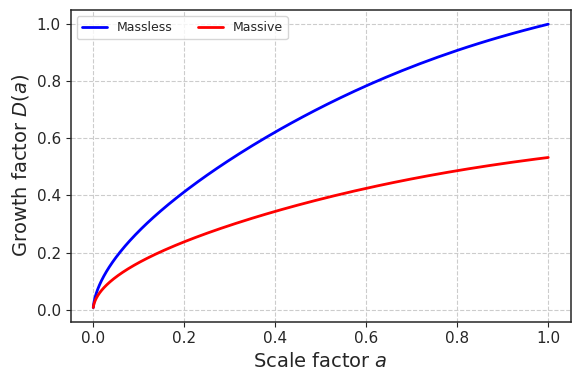

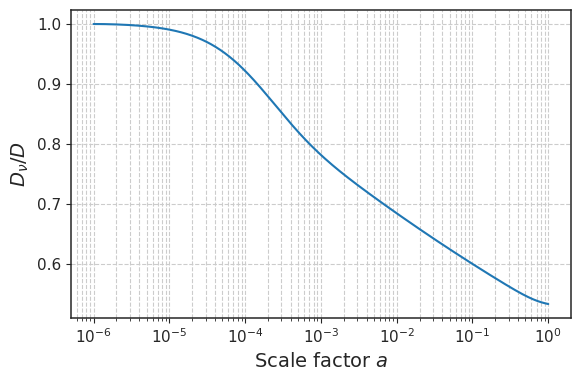

In [45]:
plt.figure(figsize=(6,4))
plt.plot(
        a,
        D,
        color="blue", lw=2, label=r'Massless'
    )
plt.plot(
        a, 
        D_nu, 
        color='red', lw=2, label=r'Massive')
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D(a)$')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,4))
plt.semilogx(
        a,
        D_nu/D
    )
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D_\nu/D$')
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

### Plot of E without free-streaming

In [ ]:
#Plot E vs E_nu
plt.figure(figsize=(6,4))
plt.plot(
        a,
        E,
        color="blue", lw=2, label=r'Massless')
plt.plot(
        a,
        E_nu,
        color='red', lw=2, label=r'Massive')
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $E(a)$')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('E.pgf')

#Plot [(E/E_nu)-1] (log scale)
plt.figure(figsize=(6,4))
plt.semilogx(a, E_nu/E , lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$E_\nu/E$')
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('E_diff.pgf')

### Growth for different masses

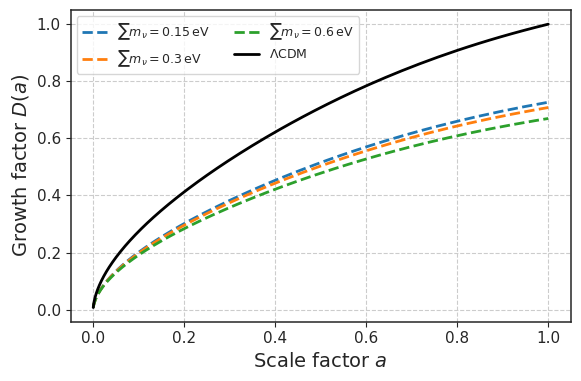

<Figure size 640x480 with 0 Axes>

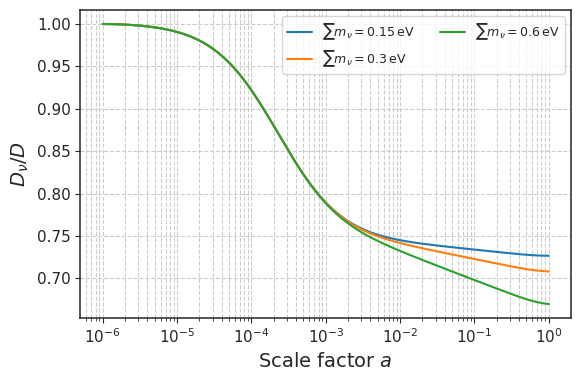

<Figure size 640x480 with 0 Axes>

In [48]:
Compute_Omega_nu(0.15/3)
sol = rk4_integrate(Ode, y0, x_array)
D = sol[:, 0]
Norm_f = D[-1]
D = D /Norm_f
sol_nu = rk4_integrate(Ode_nu, y0_nu, x_array)
results_disco = []
D_nu = sol_nu[:, 0] 
D_nu = D_nu /Norm_f
results_disco.append({
        "D": D_nu,
        "mass": 0.15,
    })
np.save("growth_1.npy", results_disco)

Compute_Omega_nu(0.3/3)
sol = rk4_integrate(Ode, y0, x_array)
D = sol[:, 0]
Norm_f = D[-1]
D = D /Norm_f
sol_nu = rk4_integrate(Ode_nu, y0_nu, x_array)
results_disco = []
D_nu = sol_nu[:, 0] 
D_nu = D_nu /Norm_f
results_disco.append({
        "D": D_nu,
        "mass": 0.3,
    })
np.save("growth_25.npy", results_disco)

Compute_Omega_nu(0.6/3)
sol = rk4_integrate(Ode, y0, x_array)
D = sol[:, 0]
Norm_f = D[-1]
D = D /Norm_f
sol_nu = rk4_integrate(Ode_nu, y0_nu, x_array)
results_disco = []
D_nu = sol_nu[:, 0] 
D_nu = D_nu /Norm_f
results_disco.append({
        "D": D_nu,
        "mass": 0.6,
    })
np.save("growth_4.npy", results_disco)

########

growth_1 = np.load("growth_1.npy", allow_pickle=True)
growth_25 = np.load("growth_25.npy", allow_pickle=True)
growth_4 = np.load("growth_4.npy", allow_pickle=True)

all_data = list(growth_1) + list(growth_25) + list(growth_4)

plt.figure(figsize=(6,4))

masses = sorted(set(d["mass"] for d in all_data))

for d in all_data:
    D1 = d["D"]
    mass = d["mass"]


    plt.plot(
        a,
        D1,
        '--', lw=2,
             label=fr"$\sum m_\nu = {mass}\,\mathrm{{eV}}$"
    )
plt.plot(a, D, color='black', lw=2, label=r'$\Lambda$CDM')
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D(a)$')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
plt.savefig('D.pgf')

plt.figure(figsize=(6,4))

for d in all_data:
    D1 = d["D"]
    mass = d["mass"]


    plt.semilogx(
        a,
        D1/D,
        label=fr"$\sum m_\nu = {mass}\,\mathrm{{eV}}$"
    )
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D_\nu/D$')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
plt.savefig('D_diff.pgf')

### Test of free-streaming functions

In [ ]:
def a_nr(m_eV):
    """Compute the scale factor for which neutrinos became non relat"""
    # a at which 3 Tnu(a) ~ m => a_nr ~ 3 Tnu0 / m
    return 3.0 * Tnu0_eV / m_eV

def v_th_kms(a, m_eV):
    """Compute the min between c and the thermal velocity """
    # v_th in km/s; cap at c while relativistic
    vnr = (3.0 * Tnu0_eV / (m_eV * a)) * c_kms  # non-relativistic scaling
    return jnp.minimum(c_kms, vnr)

def k_FS_hMpc(a):
    """Compute the free-streaming lenght in k-space"""
    H = Hubble_const_wnu(Omega_c, Omega_b, Omega_k, a) # km/s/Mpc
    v = v_th_kms(a, mnu)               # km/s
    k_Mpc_inv = jnp.sqrt(1.5) * (a*H) / v   # 1/Mpc
    return k_Mpc_inv * h  # h/Mpc

def gamma_FS(k_hMpc, a, shape="lorentz", width=0.2):
    """
    Compute the gamma factor of free-streaming
    It should be noted that the use of this gamma factor in the ODE to account for free-streaming and scale dependence is an approximation, normally, this should be done using a perturbative method. 
    """
    kfs = k_FS_hMpc(a) + 1e-30
    x2 = (k_hMpc / kfs)**2

    if shape == "lorentz":
        g = 1.0 / (1.0 + x2)
    elif shape == "exp":
        g = jnp.exp(-x2)
    else:
        g = 1.0 / (1.0 + x2)

    anr = a_nr(mnu)
    # Smooth step rising from 0 to 1 across a_nr
    s = 0.5 * (1.0 + jnp.tanh((a - anr) / (width * anr + 1e-30)))
    return  g * s  

########

def Omega_m_nu_FS(a, k):
    """
    Compute the dynamic fraction of matter with massive neutrinos and free-streaming
    It should be noted that the use of this gamma factor in the ODE to account for free-streaming and scale dependence is an approximation, normally, this should be done using a perturbative method.
    """
    Omega_cb_a = (Omega_m0 * a**(-3)) / E2_nu(a)
    Omega_nu_a = Omega_nu(a) / E2_nu(a)
    gamma = gamma_FS(k,a,'lorentz')
    return Omega_cb_a + gamma * Omega_nu_a

########
    
def Ode_nu_k(k):
    def Ode_nu(x, y):
        """ODEs of D and E in log(a) variable for massive neutrinos with free streaming"""
        D, Dx, E, Ex = y
        a = jnp.exp(x)
        Omega_eff = Omega_m_nu_FS(a, k)
        Dxx = (3/2) * Omega_eff * D - (2 + dlnHdx(a, E2_nu, fdE_da_nu)) * Dx
        Exx = (3/2) * Omega_eff * (E - D**2) - (2 + dlnHdx(a, E2_nu, fdE_da_nu)) * Ex
        return jnp.array([Dx, Dxx, Ex, Exx])
    return Ode_nu

In [ ]:
#Integration massive neutrinos with free streaming 
D_nu_k = []
E_nu_k = []
for k in k_list:
    Ode_k = Ode_nu_k(k)
    sol_k = rk4_integrate(Ode_k, y0_nu, x_array)

    Dk = sol_k[:, 0]
    Ek = sol_k[:, 2]
    
    D_nu_k.append(Dk)
    E_nu_k.append(Ek)

#D_nu_k = jnp.array(D_nu_k)
#E_nu_k = jnp.array(E_nu_k)

In [ ]:
#Computation of free-streaming variables
k_list = jnp.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1])
v = v_th_kms(a,mnu)
gamma_grid = jnp.array([gamma_FS(k_list, ai,'lorentz') for ai in a])  
kfs_grid = jnp.array([k_FS_hMpc(ai)      for ai in a])
a_np     = np.asarray(a)
k_list_np = np.asarray(k_list)
gamma_np = np.asarray(gamma_grid)
kfs_np   = np.asarray(kfs_grid)
a_nr_val = float(a_nr(mnu))
plt.figure(figsize=(7.0, 5.0))
for i, k in enumerate(k_list_np):
    plt.semilogx(a_np, gamma_np[:, i], label=f"k = {k:.3g} h/Mpc")
plt.axvline(a_nr_val, color="k", ls="--", alpha=0.6, label="a_nr")
plt.xlabel("Scale factor a")
plt.ylabel(r"$\gamma_{\mathrm{FS}}(k,a)$")
#plt.title(r"Free-streaming clustering factor $\gamma_{\mathrm{FS}}$ vs a")
plt.ylim(-0.02, 1.05)
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('FS.pgf')


### Plots of D with free streaming

In [ ]:
#Plot Plot D vs D_nu with free-streaming
plt.figure(figsize=(7.0, 5.0))
ax = plt.gca()
for i, k in enumerate(k_list):
    ax.plot(a, D_nu_k[i], label=f"k = {k:.3g} h/Mpc")
ax.plot(a, D, color='black', label='massless')
ax.set_xlabel("Scale factor a")
ax.set_ylabel(r"Normalised Growth factor $D(a)$")
ax.legend(ncol=2, fontsize=9,loc="upper left")
ax.grid(True, which='both', ls='--')
axins = inset_axes(
    ax,
    width="80%",
    height="80%",
    bbox_to_anchor=(0.5, 0.1, 0.4, 0.4),
    bbox_transform=ax.transAxes,
    borderpad=0
)
for i, k in enumerate(k_list):
    axins.semilogx(a, D_nu_k[i])
axins.semilogx(a, D, color='black')
axins.set_xticklabels([], minor=True)
axins.set_yticklabels([], minor=True)
axins.set_xticks([], minor=True)
axins.set_yticks([], minor=True)
axins.set_xlim(0.95, 0.98)
axins.set_ylim(0.0162, 0.0166)
axins.grid(True, which='both', ls='--')
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
plt.show()
#plt.savefig('D_fs.pgf')


#Plot [(D/D_nu)-1] (log scale)
plt.figure(figsize=(7.0, 5.0))
for i, k in enumerate(k_list):
    plt.semilogx(a, D_nu_k[i]/D, label=f"k = {k:.3g} h/Mpc")
plt.axvline(a_nr_val, color="k", ls="--", alpha=0.6, label="a_nr")
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D_\nu / D $')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('D_fs_diff.pgf')

### Plot of E with free streaming

In [ ]:
#Plot Plot D vs D_nu with free-streaming
plt.figure(figsize=(7.0, 5.0))
ax = plt.gca()
for i, k in enumerate(k_list):
    ax.plot(a, E_nu_k[i], label=f"k = {k:.3g} h/Mpc")
ax.plot(a, E, color='black', label='massless')
ax.set_xlabel("Scale factor a")
ax.set_ylabel(r"Normalised Growth factor $E(a)$")
ax.legend(ncol=2, fontsize=9, loc="lower left")
ax.grid(True, which='both', ls='--')
axins = inset_axes(
    ax,
    width="80%",
    height="80%",
    bbox_to_anchor=(0.55, 0.55, 0.4, 0.4),
    bbox_transform=ax.transAxes,
    borderpad=0
)
for i, k in enumerate(k_list):
    axins.semilogx(a, E_nu_k[i])
axins.semilogx(a, E, color='black')
axins.set_xticklabels([], minor=True)
axins.set_yticklabels([], minor=True)
axins.set_xticks([], minor=True)
axins.set_yticks([], minor=True)
axins.set_xlim(0.95, 0.98)
axins.set_ylim(-0.0001855, -0.0001775)
axins.grid(True, which='both', ls='--')
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.5")
plt.show()
#plt.savefig('E_fs.pgf')


#Plot [(D/D_nu)-1] (log scale)
plt.figure(figsize=(7.0, 5.0))
for i, k in enumerate(k_list):
    plt.semilogx(a, E_nu_k[i]/E, label=f"k = {k:.3g} h/Mpc")
plt.axvline(a_nr_val, color="k", ls="--", alpha=0.6, label="a_nr")
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$E_\nu/E $')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('E_fs_diff.pgf')